In [1]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import pandas as pd

In [38]:
import matplotlib.pyplot as plt
import matplotlib as mpl

cmap = mpl.cm.get_cmap('Set2')
num_colors = 8

colors = [cmap(i / num_colors) for i in range(num_colors)]
ca = colors[0]
cb = colors[2]


/tmp/ipykernel_29409/1317914952.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('Set2')


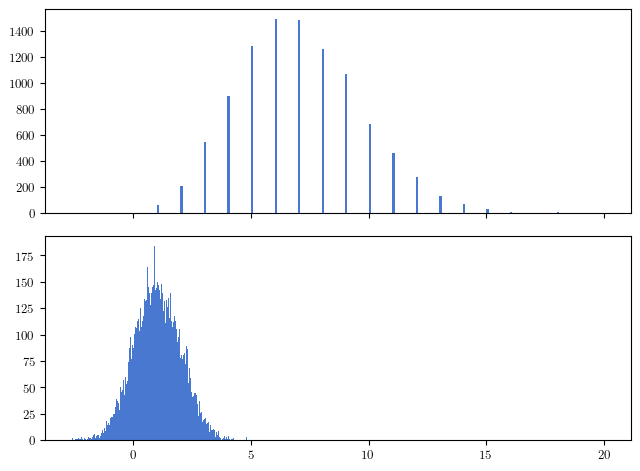

In [32]:
plt.style.use("seaborn-v0_8-muted")
def set_size(width_pt=472.31595, fraction=1, subplots=(1, 1)):
    """Set figure dimensions nicely

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5 ** .5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return fig_width_in, fig_height_in

# Colormap with University colors
colors = ["white", "#005f9b", "#153268"]
nodes = [0.0, 0.8, 1.0]
unimap = matplotlib.colors.LinearSegmentedColormap.from_list("unimap", list(zip(nodes, colors)))
unimap_r = unimap.reversed()
try:
    matplotlib.colormaps.register(cmap=unimap)
    matplotlib.colormaps.register(cmap=unimap_r)
except ValueError:
    pass

# LaTeX text renderer
plt.rcParams.update({
    "font.family": "serif",  # use serif/main font for text elements
    "font.serif": "Computer Modern Roman",
    "text.usetex": True,  # use inline math for ticks
    "text.latex.preamble": r"\usepackage{amsmath}",
    "pgf.rcfonts": False,  # don't setup fonts from rc parameters
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10.95,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    # Cmap
    "image.cmap": "unimap"
})
 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=set_size(fraction=1, subplots=(1.2, 1)), sharex=True)

ax1.hist(np.random.poisson(7, 10000), bins=200)
ax2.hist(np.random.normal(1, 1, 10000), bins=200)

plt.tight_layout()
plt.show()
fig.savefig('style.pdf', format='pdf', bbox_inches='tight', dpi=300)

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections import defaultdict

Something broke in 1x, checkpoint 2399
Slope (m):     -6.91254e-09
Intercept (b): 0.999073
R²:            0.156697


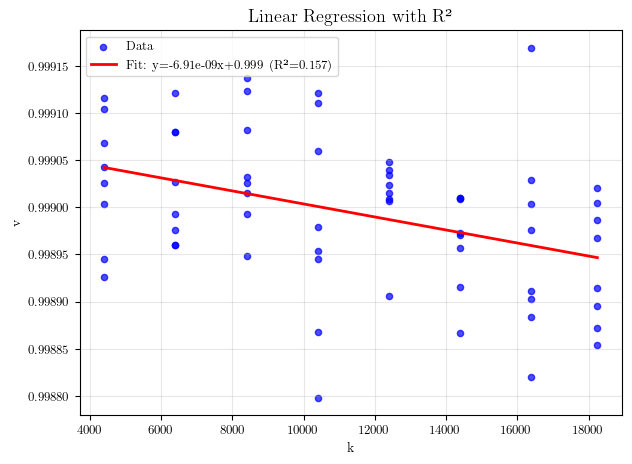

In [34]:
baseline_meanlists = {}
baseline_compute_max_map = defaultdict(list)

for checkpoint in os.listdir("data/1x/"):
    dlist = []
    
    for csvfile in os.listdir(f"data/1x/{checkpoint}/baseline/"):
        data = pd.read_csv(f"data/1x/{checkpoint}/baseline/{csvfile}")
    
        dlist.append(data["TRA"].to_list())
        baseline_compute_max_map[int(checkpoint)].append(max(data["TRA"].to_list()))

    meanlist = []
    for idx in range(max([len(x) for x in dlist])):
        i = 0
        summe = 0
        for dl in dlist:
            try:
                summe += dl[idx]
                i += 1
            except:
                pass
        meanlist.append(summe / i)
    baseline_meanlists[checkpoint] = meanlist

meanlists = {}
treatment_compute_max_map = defaultdict(list)

for checkpoint in os.listdir("data/1x/"):
    dlist = []

    try:
        for csvfile in os.listdir(f"data/1x/{checkpoint}/witheffects/"):
            data = pd.read_csv(f"data/1x/{checkpoint}/witheffects/{csvfile}")
        
            dlist.append(data["TRA"].to_list())
            treatment_compute_max_map[int(checkpoint)].append(max(data["TRA"].to_list()))
    
        meanlist = []
        for idx in range(max([len(x) for x in dlist])):
            i = 0
            summe = 0
            for dl in dlist:
                try:
                    summe += dl[idx]
                    i += 1
                except:
                    pass
            meanlist.append(summe / i)
        meanlists[checkpoint] = meanlist
    except:
        print("Something broke in 1x, checkpoint", checkpoint)

import numpy as np
import matplotlib.pyplot as plt

# --- Flatten baseline_compute_max_map into x/y arrays ---
x = []
y = []

for k, l in treatment_compute_max_map.items():
    for v in l:
        x.append(k)
        y.append(v)

x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)

if x.size < 2:
    raise ValueError("Need at least 2 (k, v) points to fit a regression.")

# --- Linear regression: y = m*x + b ---
m, b = np.polyfit(x, y, 1)
y_pred = m * x + b

# --- R^2 ---
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

print(f"Slope (m):     {m:.6g}")
print(f"Intercept (b): {b:.6g}")
print(f"R²:            {r_squared:.6g}")

# --- Plot points + regression line ---
plt.figure(figsize=(7, 5))
plt.scatter(x, y, c="blue", s=20, alpha=0.7, label="Data")

# Smooth line across the x-range
x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, c="red", linewidth=2, label=f"Fit: y={m:.3g}x+{b:.3g} (R²={r_squared:.3f})")

plt.xlabel("k")
plt.ylabel("v")
plt.title("Linear Regression with R²")
plt.grid(True, alpha=0.3)
plt.legend()


plt.savefig("transfer_learning_regression.pdf")

In [35]:
colors

['white', '#005f9b', '#153268']

=== 1x (witheffects) ===
Slope (m):     -6.91254e-09
Intercept (b): 0.999073
R²:            0.156697

=== 2x (witheffects) ===
Slope (m):     2.95028e-09
Intercept (b): 0.998985
R²:            0.0400687


/tmp/ipykernel_29409/1085489824.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('Set2')


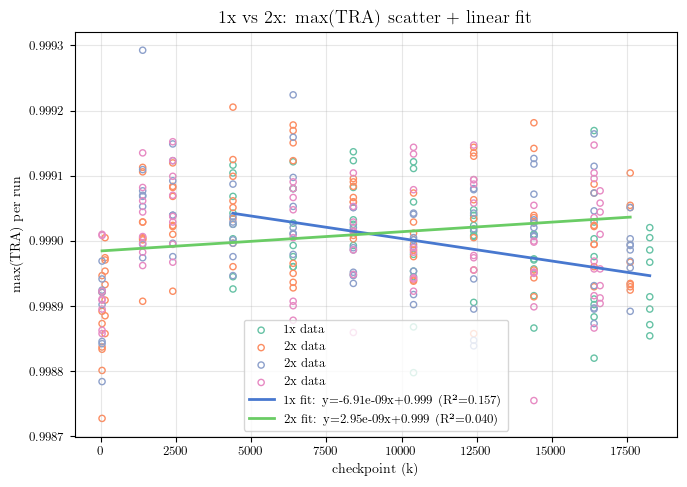

In [39]:
import os
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def collect_max_points(root_dir, variant="witheffects", col="TRA"):
    """
    Returns flattened arrays (x, y) where:
      x = checkpoint (int)
      y = max(TRA) for each csv under data/<root_dir>/<checkpoint>/<variant>/
    """
    compute_max_map = defaultdict(list)

    if not os.path.isdir(root_dir):
        raise FileNotFoundError(f"Missing directory: {root_dir}")

    for checkpoint in os.listdir(root_dir):
        checkpoint_path = os.path.join(root_dir, checkpoint)
        if not os.path.isdir(checkpoint_path):
            continue

        # checkpoint should be int-like; if not, skip
        try:
            ckpt_int = int(checkpoint)
        except ValueError:
            continue

        variant_path = os.path.join(checkpoint_path, variant)
        if not os.path.isdir(variant_path):
            # silently skip checkpoints without that subfolder
            continue

        for csvfile in os.listdir(variant_path):
            if not csvfile.lower().endswith(".csv"):
                continue
            fpath = os.path.join(variant_path, csvfile)

            data = pd.read_csv(fpath)
            if col not in data.columns:
                continue

            vals = data[col].dropna().to_numpy()
            if vals.size == 0:
                continue

            compute_max_map[ckpt_int].append(float(np.max(vals)))

    # Flatten to x/y
    x, y = [], []
    for k, lst in compute_max_map.items():
        for v in lst:
            x.append(k)
            y.append(v)

    return np.asarray(x, dtype=float), np.asarray(y, dtype=float), compute_max_map


def fit_line_and_r2(x, y):
    if x.size < 2:
        return np.nan, np.nan, np.nan

    m, b = np.polyfit(x, y, 1)
    y_pred = m * x + b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
    return m, b, r2


# --- Collect BOTH groups (1x and 2x) ---
x1, y1, _ = collect_max_points("data/1x", variant="witheffects", col="TRA")
x2, y2, _ = collect_max_points("data/2x", variant="witheffects", col="TRA")
x3, y3, _ = collect_max_points("data/3x", variant="witheffects", col="TRA")
x4, y4, _ = collect_max_points("data/4x", variant="witheffects", col="TRA")

m1, b1, r21 = fit_line_and_r2(x1, y1)
m2, b2, r22 = fit_line_and_r2(x2, y2)

print("=== 1x (witheffects) ===")
print(f"Slope (m):     {m1:.6g}")
print(f"Intercept (b): {b1:.6g}")
print(f"R²:            {r21:.6g}")
print()
print("=== 2x (witheffects) ===")
print(f"Slope (m):     {m2:.6g}")
print(f"Intercept (b): {b2:.6g}")
print(f"R²:            {r22:.6g}")

# --- Plot ---
plt.figure(figsize=(7, 5))

cmap = mpl.cm.get_cmap('Set2')
num_colors = 8

colors = [cmap(i / num_colors) for i in range(num_colors)]
ca = colors[0]
cb = colors[2]

plt.scatter(x1, y1, s=20, alpha=1.0, label="1x data", facecolors='none', edgecolors=colors[0])
plt.scatter(x2, y2, s=20, alpha=1.0, label="2x data", facecolors='none', edgecolors=colors[1])
plt.scatter(x3, y3, s=20, alpha=1.0, label="2x data", facecolors='none', edgecolors=colors[2])
plt.scatter(x4, y4, s=20, alpha=1.0, label="2x data", facecolors='none', edgecolors=colors[3])

# Fit lines (each on its own x-range for clarity)
if np.isfinite(m1) and np.isfinite(b1):
    x1_line = np.linspace(x1.min(), x1.max(), 200)
    plt.plot(x1_line, m1 * x1_line + b1, linewidth=2,
             label=f"1x fit: y={m1:.3g}x+{b1:.3g} (R²={r21:.3f})")

if np.isfinite(m2) and np.isfinite(b2):
    x2_line = np.linspace(x2.min(), x2.max(), 200)
    plt.plot(x2_line, m2 * x2_line + b2, linewidth=2,
             label=f"2x fit: y={m2:.3g}x+{b2:.3g} (R²={r22:.3f})")

plt.xlabel("checkpoint (k)")
plt.ylabel("max(TRA) per run")
plt.title("1x vs 2x: max(TRA) scatter + linear fit")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("transfer_learning_regression_1x_vs_2x.pdf")
plt.show()


=== 1x ===
Michaelis–Menten: y = y0 + (A*x)/(K + x)
y0: 0.999073
A:  -0.0252328
K:  3.62889e+06
R²: 0.156633

=== 2x ===
Michaelis–Menten: y = y0 + (A*x)/(K + x)
y0: 0.998683
A:  0.000350785
K:  52.2055
R²: 0.346119

=== 3x ===
Michaelis–Menten: y = y0 + (A*x)/(K + x)
y0: 0.979298
A:  0.019722
K:  0.315157
R²: 0.175225

=== 4x ===
Michaelis–Menten: y = y0 + (A*x)/(K + x)
y0: 0.97938
A:  0.019632
K:  0.220697
R²: 0.0995599

0
1
2
3
0
1
2
3


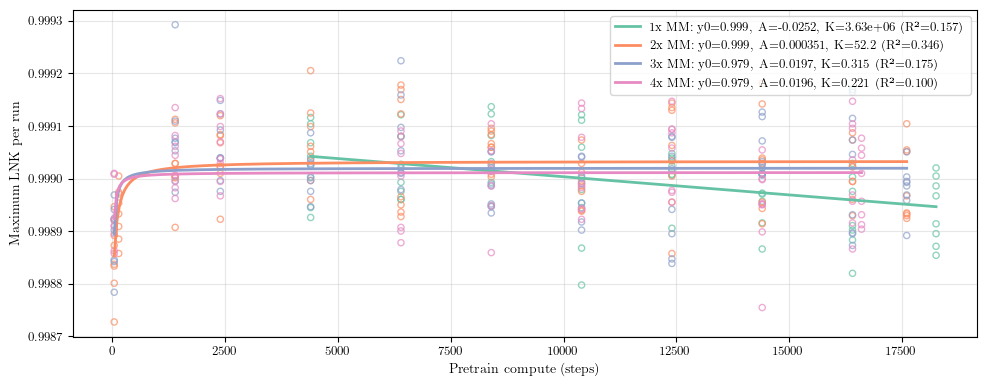

In [63]:
import os
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def collect_max_points(root_dir, variant="witheffects", col="TRA"):
    """
    Returns flattened arrays (x, y) where:
      x = checkpoint (int)
      y = max(TRA) for each csv under data/<root_dir>/<checkpoint>/<variant>/
    Also returns compute_max_map: {checkpoint: [max1, max2, ...]}
    """
    compute_max_map = defaultdict(list)

    if not os.path.isdir(root_dir):
        raise FileNotFoundError(f"Missing directory: {root_dir}")

    for checkpoint in os.listdir(root_dir):
        checkpoint_path = os.path.join(root_dir, checkpoint)
        if not os.path.isdir(checkpoint_path):
            continue

        try:
            ckpt_int = int(checkpoint)
        except ValueError:
            continue

        variant_path = os.path.join(checkpoint_path, variant)
        if not os.path.isdir(variant_path):
            continue

        for csvfile in os.listdir(variant_path):
            if not csvfile.lower().endswith(".csv"):
                continue
            fpath = os.path.join(variant_path, csvfile)

            data = pd.read_csv(fpath)
            if col not in data.columns:
                continue

            vals = data[col].dropna().to_numpy()
            if vals.size == 0:
                continue

            compute_max_map[ckpt_int].append(float(np.max(vals)))

    x, y = [], []
    for k, lst in compute_max_map.items():
        for v in lst:
            x.append(k)
            y.append(v)

    return np.asarray(x, dtype=float), np.asarray(y, dtype=float), compute_max_map


def michaelis_menten(x, y0, A, K):
    """y = y0 + (A*x)/(K + x)"""
    x = np.asarray(x, dtype=float)
    return y0 + (A * x) / (K + x)


def fit_mm_and_r2(x, y, bounds=([0.0, -1.0, 0.0], [1.0, 1.0, np.inf])):
    """
    Fits Michaelis–Menten. Returns:
      (y0, A, K), r2, covariance_matrix
    """
    if x.size < 3:
        return (np.nan, np.nan, np.nan), np.nan, None

    # Initial guesses
    y0_init = float(np.min(y))
    A_init  = float(np.max(y) - np.min(y))
    K_init  = float(np.median(x[x > 0])) if np.any(x > 0) else 1.0
    p0 = [y0_init, A_init, K_init]

    params, cov = curve_fit(
        michaelis_menten,
        x, y,
        p0=p0,
        bounds=bounds,
        maxfev=20000
    )
    y0_hat, A_hat, K_hat = params

    y_pred = michaelis_menten(x, y0_hat, A_hat, K_hat)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

    return (y0_hat, A_hat, K_hat), r2, cov


def summarize_group(label, x, y, params, r2):
    y0, A, K = params
    print(f"=== {label} ===")
    print("Michaelis–Menten: y = y0 + (A*x)/(K + x)")
    print(f"y0: {y0:.6g}")
    print(f"A:  {A:.6g}")
    print(f"K:  {K:.6g}")
    print(f"R²: {r2:.6g}")
    print()


# --- Collect four groups ---
groups = {
    "1x": collect_max_points("data/1x", variant="witheffects", col="TRA"),
    "2x": collect_max_points("data/2x", variant="witheffects", col="TRA"),
    "3x": collect_max_points("data/3x", variant="witheffects", col="TRA"),
    "4x": collect_max_points("data/4x", variant="witheffects", col="TRA"),
}

# --- Fit MM for each group ---
fit_results = {}
for label, (xg, yg, _) in groups.items():
    params, r2, cov = fit_mm_and_r2(xg, yg)
    fit_results[label] = {"params": params, "r2": r2, "cov": cov}
    summarize_group(label, xg, yg, params, r2)

# --- Plot scatter + MM curves ---
plt.figure(figsize=(10, 4))

# Scatter styling (matplotlib default cycle handles colors)
idx = 0
for label, (xg, yg, _) in groups.items():
    plt.scatter(xg, yg, s=20, alpha=0.7, label=f"_nolegend_", facecolors='none', edgecolors=colors[idx])
    print(idx)
    idx += 1

# Overlay fitted curves on each group’s x-range
idx = 0
for label, (xg, yg, _) in groups.items():
    params = fit_results[label]["params"]
    r2 = fit_results[label]["r2"]
    if not np.all(np.isfinite(params)):
        continue

    x_line = np.linspace(xg.min(), xg.max(), 300)
    y_line = michaelis_menten(x_line, *params)
    y0, A, K = params
    plt.plot(
        x_line, y_line, linewidth=2,
        label=f"{label} MM: y0={y0:.3g}, A={A:.3g}, K={K:.3g} (R²={r2:.3f})",
        color=colors[idx]
    )
    print(idx)
    idx += 1

plt.xlabel("Pretrain compute (steps)")
plt.ylabel("Maximum LNK per run")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("feb_mm_full.pdf")
plt.show()


=== 2x ===
Michaelis–Menten: y = y0 + (A*x)/(K + x)
y0: 0.998749
A:  0.000298682
K:  89.8967
R²: 0.625523

=== 3x ===
Michaelis–Menten: y = y0 + (A*x)/(K + x)
y0: 0.972712
A:  0.0263614
K:  0.340311
R²: 0.581068

=== 4x ===
Michaelis–Menten: y = y0 + (A*x)/(K + x)
y0: 0.998912
A:  0.000207012
K:  983.134
R²: 0.529194



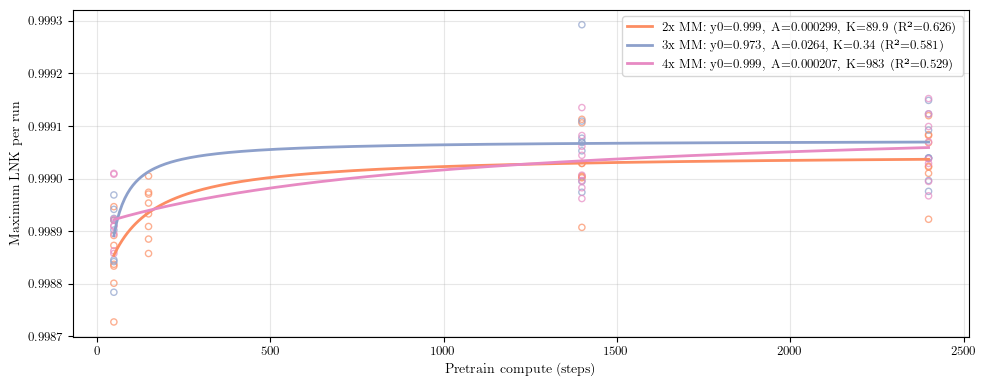

In [62]:
import os
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def collect_max_points(root_dir, variant="witheffects", col="TRA"):
    compute_max_map = defaultdict(list)

    if not os.path.isdir(root_dir):
        raise FileNotFoundError(f"Missing directory: {root_dir}")

    for checkpoint in os.listdir(root_dir):
        checkpoint_path = os.path.join(root_dir, checkpoint)
        if not os.path.isdir(checkpoint_path):
            continue

        try:
            ckpt_int = int(checkpoint)
        except ValueError:
            continue

        variant_path = os.path.join(checkpoint_path, variant)
        if not os.path.isdir(variant_path):
            continue

        for csvfile in os.listdir(variant_path):
            if not csvfile.lower().endswith(".csv"):
                continue
            fpath = os.path.join(variant_path, csvfile)

            data = pd.read_csv(fpath)
            if col not in data.columns:
                continue

            vals = data[col].dropna().to_numpy()
            if vals.size == 0:
                continue

            compute_max_map[ckpt_int].append(float(np.max(vals)))

    x, y = [], []
    for k, lst in compute_max_map.items():
        for v in lst:
            x.append(k)
            y.append(v)

    return np.asarray(x, dtype=float), np.asarray(y, dtype=float), compute_max_map


def michaelis_menten(x, y0, A, K):
    return y0 + (A * x) / (K + x)


def fit_mm_and_r2(x, y, bounds=([0.0, -1.0, 0.0], [1.0, 1.0, np.inf])):
    if x.size < 3:
        return (np.nan, np.nan, np.nan), np.nan, None

    y0_init = float(np.min(y))
    A_init  = float(np.max(y) - np.min(y))
    K_init  = float(np.median(x[x > 0])) if np.any(x > 0) else 1.0
    p0 = [y0_init, A_init, K_init]

    params, cov = curve_fit(
        michaelis_menten,
        x, y,
        p0=p0,
        bounds=bounds,
        maxfev=20000
    )
    y0_hat, A_hat, K_hat = params

    y_pred = michaelis_menten(x, y0_hat, A_hat, K_hat)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

    return (y0_hat, A_hat, K_hat), r2, cov


def summarize_group(label, params, r2):
    y0, A, K = params
    print(f"=== {label} ===")
    print("Michaelis–Menten: y = y0 + (A*x)/(K + x)")
    print(f"y0: {y0:.6g}")
    print(f"A:  {A:.6g}")
    print(f"K:  {K:.6g}")
    print(f"R²: {r2:.6g}")
    print()


# -----------------------------
# Config: skip 1x, limit ckpt <= 2600
# -----------------------------
MAX_CKPT = 2600
INCLUDE = ["2x", "3x", "4x"]  # skip 1x

group_dirs = {
    "1x": "data/1x",
    "2x": "data/2x",
    "3x": "data/3x",
    "4x": "data/4x",
}

# --- Collect + filter groups ---
groups = {}
for label in INCLUDE:
    xg, yg, mmap = collect_max_points(group_dirs[label], variant="witheffects", col="TRA")

    # Filter: only checkpoints <= 2600
    mask = xg <= MAX_CKPT
    xg = xg[mask]
    yg = yg[mask]

    groups[label] = (xg, yg)

# --- Fit MM for each group (on filtered data) ---
fit_results = {}
for label, (xg, yg) in groups.items():
    params, r2, cov = fit_mm_and_r2(xg, yg)
    fit_results[label] = {"params": params, "r2": r2, "cov": cov}
    summarize_group(label, params, r2)

# --- Plot scatter + MM curves ---
plt.figure(figsize=(10, 4))

idx = 0
for label, (xg, yg) in groups.items():
    plt.scatter(xg, yg, s=20, alpha=0.7, label=f"_nolabel_", color=colors[idx+1], facecolors='none',)
    idx += 1

idx = 0
for label, (xg, yg) in groups.items():
    params = fit_results[label]["params"]
    r2 = fit_results[label]["r2"]
    if not np.all(np.isfinite(params)) or xg.size < 3:
        continue

    x_line = np.linspace(xg.min(), xg.max(), 300)
    y_line = michaelis_menten(x_line, *params)
    y0, A, K = params
    plt.plot(
        x_line, y_line, linewidth=2,
        label=f"{label} MM: y0={y0:.3g}, A={A:.3g}, K={K:.3g} (R²={r2:.3f})",
        color=colors[idx+1]
    )
    idx += 1

plt.xlabel("Pretrain compute (steps)")
plt.ylabel("Maximum LNK per run")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"feb_mm_reduced.pdf")
plt.show()
